In [216]:
import pandas as pd
import numpy as np
import math
import operator
import os
import seaborn as sns

In [217]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.datasets import load_digits
from sklearn.metrics import pairwise_distances
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer
from keybert import KeyBERT
from keybert._mmr import mmr
from keybert._maxsum import max_sum_distance
from keybert._highlight import highlight_document
from keybert.backend._utils import select_backend
from tqdm import tqdm
from typing import List, Union, Tuple
from matplotlib import pyplot as plt
from scipy import linalg
from scipy.spatial.distance import squareform
from scipy.spatial.distance import pdist

In [218]:
model = SentenceTransformer('all-mpnet-base-v2')

Loading weights: 100%|█████████| 199/199 [00:00<00:00, 9043.46it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [219]:
pd.options.display.max_colwidth = 250
texts_path = 'Data/Georgian/GeorgianNews/'
#poems_path = texts_path + 'Poems/revised/'

In [220]:
import re
news_path = "en/eng_expert_IPN_news/" #"ge/ge_original_IPN_news/ OR en/eng_expert_IPN_news/"
df = pd.read_csv(texts_path + news_path + "IPN_news_combined_master_eng.csv") #"IPN_news_combined_master_ge.csv"
    
def rename_ipn_source(source):
    #Matches an underscore followed by digits at the very end before .csv
    match = re.search(r'_(\d+)\.csv$', source)
    
    if match:
        original_digits = match.group(1)
        num = int(original_digits)
        # Strip the '_01.csv' from the end and replace with '.csv'
        # "eng_Irakli_Kobakhidze_01.csv" --> "eng_Irakli_Kobakhidze.csv"
        cleaned_source = re.sub(r'_\d+\.csv$', '.csv', source)
        
        # Prepend the formatted number
        return f"{num:02d}_{cleaned_source}"
    
    return source
    
df["Source File"] = df["Source File"].apply(rename_ipn_source)

df.to_csv(texts_path + news_path + "IPN_news_combined_master_eng_renamed.csv", index=False, encoding="utf-8-sig")
#"IPN_news_combined_master_ge_renamed.csv"
print(df["Source File"].unique())

['01_ge_Irakli_Kobakhidze.csv' '02_ge_Giorgi_Sharashidze.csv'
 '03_ge_Mariam_Kvrivishvili.csv' '04_ge_Maka_Botchorishvili.csv'
 '05_ge_Archpriest_Andria.csv' '06_ge_Armaz_Akhvlediani.csv'
 '07_ge_Giorgi_Sharashidze.csv' '08_ge_Classification_wine.csv'
 '09_ge_Grigol_Gegelia.csv' '10_ge_Shalva_Papuashvili.csv'
 '11_ge_Khatia_Dekanoidze.csv' '12_ge_Irakli_Kupradze.csv'
 '13_ge_Levan_Makhashvili.csv']


In [221]:
texts_path = 'Data/Georgian/GeorgianNews/'
poem_names = []
sources = ['orig/', 'en/', 'ggl/', 'gem/', 'gpt/']
#ge_1tv_csv = texts_path + "ge/ge_original_1tv_news/combined_all_articles_ge.csv"
#ge_IPN_csv = texts_path + "ge/ge_original_IPN_news/IPN_news_combined_master_ge_renamed.csv"

#df_1tv_ge = pd.read_csv(ge_1tv_csv)
#df_IPN_ge = pd.read_csv(ge_IPN_csv)

#df_ge = pd.concat([df_1tv_ge, df_IPN_ge], axis = 0)
#print(df_ge.head())
#print(df_ge.columns)

def combine_news(lang_1tv, lang_ipn):
    onetv_lang = pd.read_csv(lang_1tv)
    ipn_lang = pd.read_csv(lang_ipn)
    
    df_ge = pd.concat([onetv_lang, ipn_lang], axis = 0)
    print(df_ge.head())
    print(df_ge.columns)
    return df_ge

df_orig = combine_news(texts_path + "orig/ge_original_1tv_news/combined_all_articles_ge.csv", texts_path + "orig/ge_original_IPN_news/IPN_news_combined_master_ge_renamed.csv")
df_en = combine_news(texts_path + "en/eng_expert_1tv_news/combined_all_articles_eng.csv", texts_path + "en/eng_expert_IPN_news/IPN_news_combined_master_eng_renamed.csv")
df_gem = combine_news(texts_path + "gem/gem_1tv_news/combined_all_articles_gem.csv", texts_path + "gem/gem_IPN_news/IPN_news_combined_master_gem_renamed.csv")
df_ggl = combine_news(texts_path + "ggl/ggl_1tv_news/combined_all_articles_ggl.csv", texts_path + "ggl/ggl_IPN_news/IPN_news_combined_master_ggl_renamed.csv")
df_gpt = combine_news(texts_path + "gpt/gpt_1tv_news/combined_all_articles_gpt.csv", texts_path + "gpt/gpt_IPN_news/IPN_news_combined_master_gpt_renamed.csv")
article_names = sorted(df_ge["Source File"].unique())
print(article_names)
print(len(article_names))

                      Source File  \
0  01_deputy_economy_minister.csv   
1  01_deputy_economy_minister.csv   
2  01_deputy_economy_minister.csv   
3  01_deputy_economy_minister.csv   
4  01_deputy_economy_minister.csv   

                                                                                                                                                                                                                                                     Content  
0                                                            ვახტანგ ცინცაძე - აზიის განვითარების ბანკის ანგარიშში ხაზგასმულია საქართველოს მიმზიდველი ბიზნესგარემო, ასევე მიმდინარე ინფრასტრუქტურული პროექტები, მათ შორის საპორტო და სარკინიგზო მიმართულებით  
1  აზიის განვითარების ბანკმა აზიის ეკონომიკური პერსპექტივების ანგარიში გამოაქვეყნა, რომლის თანახმად, 2025 წელს ეკონომიკური ზრდა იყო საკმაოდ მაღალი – 7.5 პროცენტი, ხოლო 2026 წელს, მიმდინარე კონფლიქტების ფონზე, აზიის განვითარების ბანკი ელოდება, რომ სა...  
2           

In [222]:
def table(article_names):
    print('Number of paragraphs')
    print('==============================================================================================')
    print('ID\tOrig\tEnglish\tGoogle\tGemini\tChatGPT\tPassed?\tArticle Name') #replace with Bulgarian
    
    dfs = {
        "Original": df_orig,
        "English": df_en,
        "Google": df_ggl,
        "Gemini": df_gem,
        "ChatGPT": df_gpt
    }
    
    for article in article_names:
        output = [article[:2]]
        counts = []
    
        for name, df in dfs.items():
            count = len(df[df["Source File"] == article])
            counts.append(count)
            output.append(str(count))
    
        if len(set(counts)) > 1:
            output.append("No")
    
        else:
            output.append("Yes")
    
        article_title = article[3:-4].replace('_', ' ').title()
        output.append(article_title)
       
        print('\t'.join(output))

    return df_orig, df_en, df_ggl, df_gem, df_gpt

df_orig, df_en, df_ggl, df_gem, df_gpt = table(article_names)

Number of paragraphs
ID	Orig	English	Google	Gemini	ChatGPT	Passed?	Article Name
01	6	6	6	6	6	Yes	Deputy Economy Minister
01	8	8	8	8	8	Yes	Ge Irakli Kobakhidze
02	9	9	9	9	9	Yes	Ge Giorgi Sharashidze
02	8	8	8	8	8	Yes	Georgia To Recognise
03	7	7	7	7	7	Yes	Ge Mariam Kvrivishvili
03	4	4	4	4	4	Yes	Good Friday
04	10	10	10	10	10	Yes	Ge Maka Botchorishvili
04	9	9	9	9	9	Yes	Metropolitan Shio
05	9	9	9	9	9	Yes	Ge Archpriest Andria
05	10	10	10	10	10	Yes	People Power
06	9	9	9	9	9	Yes	Ge Armaz Akhvlediani
06	6	6	6	6	6	Yes	Tbilisi Offers Free Metro
07	9	9	9	9	9	Yes	Ge Giorgi Sharashidze
07	3	3	3	3	3	Yes	Trailers And Semi-Trailers
08	10	10	10	10	10	Yes	Ge Classification Wine
08	5	5	5	5	5	Yes	Vehicle Movement
09	6	6	6	6	6	Yes	Ge Grigol Gegelia
09	6	6	6	6	6	Yes	Vespers Of The Descent
10	50	50	50	50	50	Yes	Ge Shalva Papuashvili
10	4	4	4	4	4	Yes	Water Polo
11	4	4	4	4	4	Yes	Ge Khatia Dekanoidze
12	11	11	11	11	11	Yes	Ge Irakli Kupradze
13	7	7	7	7	7	Yes	Ge Levan Makhashvili


In [223]:
def paragraphs_func(article_names, df_orig, df_en, df_ggl, df_gem, df_gpt):
    
    df = pd.DataFrame(
        columns=[
            'Article ID',
            'Article Name',
            'Paragraph',
            'Original',
            'English',
            'Google',
            'Gemini',
            'ChatGPT',
            'English - Google',
            'English - Gemini',
            'English - ChatGPT',
        ]
    )
    
    for article in article_names:
        article_id = int(article[:2])
        article_name = article[3:-4].replace('_', ' ').title()
    
        article_orig = (df_orig[df_orig["Source File"] == article]["Content"]
                     .fillna("")
                     .astype(str)
                     .str.strip() #removes all leading and trailing whitespace
                     .tolist()
                     )
    
        article_en = (
            df_en[df_en["Source File"] == article]["Content"]
            .fillna("")
            .astype(str)
            .str.strip()
            .tolist()
        )
    
        article_ggl = (
            df_ggl[df_ggl["Source File"] == article]["Translated Content"]
            .fillna("")
            .astype(str)
            .str.strip()
            .tolist()
        )
    
        article_gem = (
            df_gem[df_gem["Source File"] == article]["Translated Content"]
            .fillna("")
            .astype(str)
            .str.strip()
            .tolist()
        )
    
        article_gpt = (
            df_gpt[df_gpt["Source File"] == article]["Translated Content"]
            .fillna("")
            .astype(str)
            .str.strip()
            .tolist()
        )
        
        
        for i in range(len(article_orig)):
            row = {
                'Article ID': [article_id],
                'Article Name': [article_name],
                'Paragraph': [i + 1],
                'Original': [article_orig[i]],
                'English': [article_en[i]],
                'Google': [article_ggl[i]],
                'Gemini': [article_gem[i]],
                'ChatGPT': [article_gpt[i]],
            }
            df_new = pd.DataFrame(row)
            df = pd.concat([df, df_new], ignore_index = True)
    
    df.shape
    return df

df = paragraphs_func(article_names, df_orig, df_en, df_ggl, df_gem, df_gpt)
print(df)

    Article ID             Article Name Paragraph  \
0            1  Deputy Economy Minister         1   
1            1  Deputy Economy Minister         2   
2            1  Deputy Economy Minister         3   
3            1  Deputy Economy Minister         4   
4            1  Deputy Economy Minister         5   
..         ...                      ...       ...   
205         13     Ge Levan Makhashvili         3   
206         13     Ge Levan Makhashvili         4   
207         13     Ge Levan Makhashvili         5   
208         13     Ge Levan Makhashvili         6   
209         13     Ge Levan Makhashvili         7   

                                                                                                                                                                                                                                                      Original  \
0                                                              ვახტანგ ცინცაძე - აზიის განვითარების ბანკი

In [224]:
df.to_csv('results/all_ge_news.csv', index = False)

In [225]:
from sklearn.metrics.pairwise import cosine_similarity
import os
import pandas as pd
import numpy as np

def cosine_sim(df_csv, model, OUTPUT):
    os.makedirs(os.path.dirname(OUTPUT), exist_ok=True)

    df = pd.read_csv(df_csv)

    text_cols = ["English", "Google", "Gemini", "ChatGPT"]

    for col in text_cols:
        df[col] = df[col].fillna("").astype(str).str.strip()

    english_embeddings = model.encode(df["English"].tolist())
    google_embeddings = model.encode(df["Google"].tolist())
    gemini_embeddings = model.encode(df["Gemini"].tolist())
    chatgpt_embeddings = model.encode(df["ChatGPT"].tolist())

    df["English - Google"] = [
        cosine_similarity([english_embeddings[i]], [google_embeddings[i]])[0][0]
        #if df.at[i, "English"] != "" and df.at[i, "Google"] != ""
        #else np.nan
        for i in range(len(df))
    ]

    df["English - Gemini"] = [
        cosine_similarity([english_embeddings[i]], [gemini_embeddings[i]])[0][0]
        #if df.at[i, "English"] != "" and df.at[i, "Gemini"] != ""
        #else np.nan
        for i in range(len(df))
    ]

    df["English - ChatGPT"] = [
        cosine_similarity([english_embeddings[i]], [chatgpt_embeddings[i]])[0][0]
        #if df.at[i, "English"] != "" and df.at[i, "ChatGPT"] != ""
        #else np.nan
        for i in range(len(df))
    ]

    df.to_csv(OUTPUT, index=False)

    return df
    
df = cosine_sim('results/all_ge_news.csv', model, 'results/ge_news/similarity/cosine_similarity.csv')

In [226]:
def mean_std(df):
    df_mean_english_google = df.groupby('Article Name')['English - Google'].mean().reset_index()
    df_mean_english_gemini = df.groupby('Article Name')['English - Gemini'].mean().reset_index()
    df_mean_english_chatgpt = df.groupby('Article Name')['English - ChatGPT'].mean().reset_index()
    
    df_std_english_google = df.groupby('Article Name')['English - Google'].std().reset_index()
    df_std_english_gemini = df.groupby('Article Name')['English - Gemini'].std().reset_index()
    df_std_english_chatgpt = df.groupby('Article Name')['English - ChatGPT'].std().reset_index()

    #print(df_mean_english_google)

    # Article-Wise Mean Cosine Similarity Scores
    df_mean_english_google.shape
    table = pd.concat([df_mean_english_google, df_std_english_google, df_mean_english_gemini, df_std_english_gemini,
                      df_mean_english_chatgpt, df_std_english_chatgpt], axis = 1)
    table.drop(columns = ["Article Name"], inplace = True)
    table = pd.concat([df_mean_english_google["Article Name"], table], axis = 1)
    table.index = table.index + 1
    
    print(table)
    
    # Average Cosine Similarity Scores
    print('Google', df_mean_english_google['English - Google'].mean(), df_std_english_google['English - Google'].mean())
    print('Gemini', df_mean_english_gemini['English - Gemini'].mean(), df_std_english_gemini['English - Gemini'].mean())
    print('ChatGPT', df_mean_english_chatgpt['English - ChatGPT'].mean(), df_std_english_chatgpt['English - ChatGPT'].mean())

mean_std(df)

                  Article Name  English - Google  English - Google  \
1      Deputy Economy Minister          0.857733          0.105226   
2         Ge Archpriest Andria          0.897012          0.059820   
3         Ge Armaz Akhvlediani          0.865541          0.057159   
4       Ge Classification Wine          0.920288          0.076320   
5        Ge Giorgi Sharashidze          0.866020          0.063027   
6            Ge Grigol Gegelia          0.922037          0.077965   
7         Ge Irakli Kobakhidze          0.913890          0.057992   
8           Ge Irakli Kupradze          0.968158          0.026831   
9         Ge Khatia Dekanoidze          0.973665          0.043045   
10        Ge Levan Makhashvili          0.957610          0.068103   
11      Ge Maka Botchorishvili          0.935094          0.045702   
12      Ge Mariam Kvrivishvili          0.991343          0.009656   
13       Ge Shalva Papuashvili          0.953391          0.058293   
14        Georgia To

In [227]:
def max_min_cos(df):
    max_cos_sim_eng_ggl = df['English - Google'].max()
    max_cos_sim_eng_gem = df['English - Gemini'].max()
    max_cos_sim_eng_gpt = df['English - ChatGPT'].max()
    
    min_cos_sim_eng_ggl = df['English - Google'].min()
    min_cos_sim_eng_gem = df['English - Gemini'].min()
    min_cos_sim_eng_gpt = df['English - ChatGPT'].min()
    
    print('Google', max_cos_sim_eng_ggl, min_cos_sim_eng_ggl)
    print('Gemini', max_cos_sim_eng_gem, min_cos_sim_eng_gem)
    print('ChatGPT', max_cos_sim_eng_gpt, min_cos_sim_eng_gpt)
    df['Sum CS'] = df['English - Google'] + df['English - Gemini'] + df['English - ChatGPT']

    #Most, Least Semantically Similar Verses
    min_sum_cs = df.sort_values(by = 'Sum CS').head(3)
    max_sum_cs = df.sort_values(by = 'Sum CS', ascending=False).iloc[:3, ]
    print(min_sum_cs)
    print(max_sum_cs)

max_min_cos(df)

Google 1.0000001 0.55346817
Gemini 0.99913573 0.19850677
ChatGPT 1.0000002 0.5063251
     Article ID               Article Name  Paragraph  \
94            6  Tbilisi Offers Free Metro          6   
128           9     Vespers Of The Descent          1   
117           8           Vehicle Movement          1   

                                                                                                                                 Original  \
94   აღნიშნული მარშრუტების ავტობუსებით მოქალაქეები ორი დღის განმავლობაში უფასოდ ისარგებლებენ“, – აღნიშნულია თბილისის მერიის ინფორმაციაში.   
128                                                                                  სამების საკათედრო ტაძარში გარდამოხსნის წესი შესრულდა   
117                                                                  გუდაური (ფოსტა)-კობის მონაკვეთზე ავტოტრანსპორტის მოძრაობა აკრძალულია   

                                                                                                              English  \


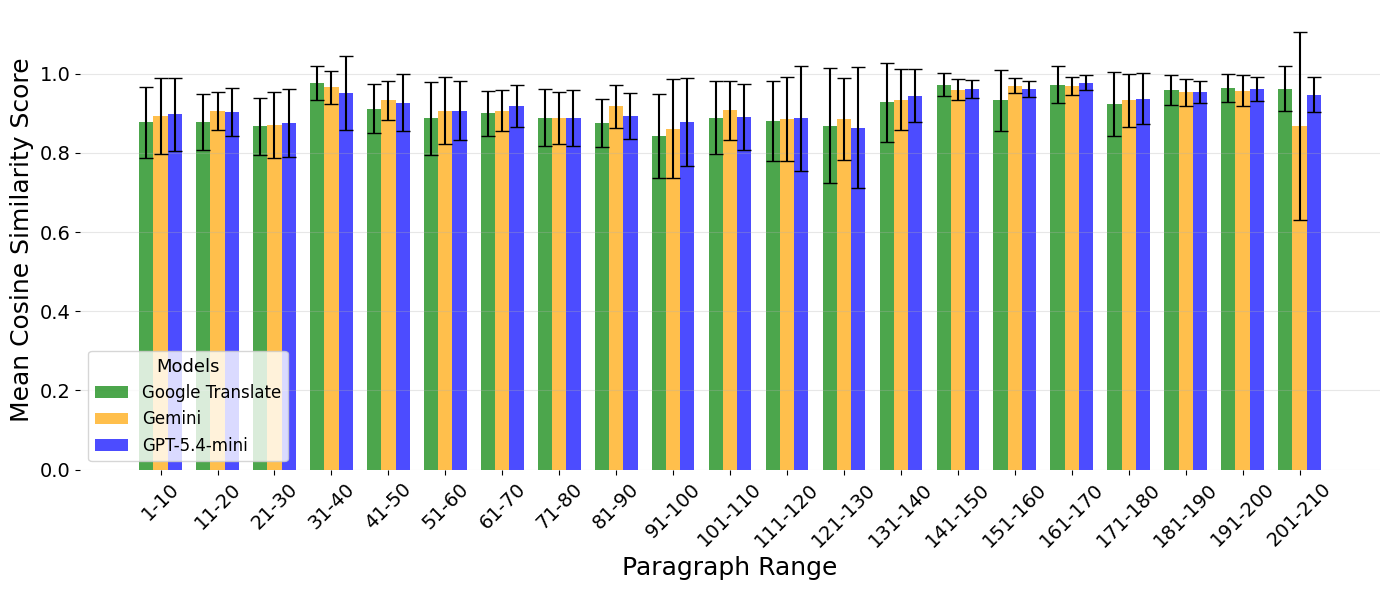

In [228]:
def plot_error_bar_graph(
    file_path,
    output_path,
    score_columns=None,
    model_labels=None,
    bin_size=10
):
    df = pd.read_csv(file_path)

    if score_columns is None:
        score_columns = [
            "English - Google",
            "English - Gemini",
            "English - ChatGPT"
        ]

    if model_labels is None:
        model_labels = [
            "Google Translate",
            "Gemini",
            "GPT-5.4-mini"
        ]

    min_rows = len(df)

    num_full_bins = min_rows // bin_size
    remaining_rows = min_rows % bin_size

    bins = [
        (i * bin_size, (i + 1) * bin_size)
        for i in range(num_full_bins)
    ]

    if remaining_rows:
        bins.append((num_full_bins * bin_size, min_rows))

    bin_labels = [
        f"{start + 1}-{end}"
        for start, end in bins
    ]

    mean_scores = []
    std_devs = []

    for col in score_columns:
        means = [
            df[col].iloc[start:end].mean()
            for start, end in bins
        ]

        stds = [
            df[col].iloc[start:end].std()
            for start, end in bins
        ]

        mean_scores.append(means)
        std_devs.append(stds)

    mean_scores = np.array(mean_scores)
    std_devs = np.array(std_devs)

    x = np.arange(len(bins))
    width = 0.25

    fig, ax = plt.subplots(figsize=(14, 6))

    colors = ["green", "orange", "blue"]

    for i in range(len(score_columns)):
        ax.bar(
            x + i * width,
            mean_scores[i],
            width=width,
            yerr=std_devs[i],
            capsize=5,
            label=model_labels[i],
            color=colors[i],
            alpha=0.7
        )

    ax.set_xticks(x + width)
    ax.set_xticklabels(bin_labels, rotation=45)

    ax.set_xlabel("Paragraph Range", fontsize=18)
    ax.set_ylabel("Mean Cosine Similarity Score", fontsize=18)

    ax.tick_params(axis="x", labelsize=14)
    ax.tick_params(axis="y", labelsize=14)

    ax.legend(
        title="Models",
        fontsize=12,
        title_fontsize=13
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    ax.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_path, bbox_inches="tight", dpi=300)
    plt.show()

plot_error_bar_graph(
    file_path="results/ge_news/similarity/cosine_similarity.csv",
    output_path="results/ge_news/similarity/cosine_similarity_errorbars.png",
    bin_size=10
)

In [229]:
#Bulgarian News

texts_path = 'Data/Bulgarian/BulgarianNews/'
file_paths = ["orig/BTA_news_combined_master_bul.csv", 
              "en/BTA_news_combined_master_eng.csv",
              "gem/BTA_news_combined_master_gem.csv",
              "ggl/BTA_news_combined_master_ggl.csv",
              "gpt/BTA_news_combined_master_gpt.csv"]

OUTPUT_BASE = 'results/bul_news/sentiment/'

for file in file_paths:
    df = pd.read_csv(texts_path + file)
    df["Source File"] = df["Source File"].apply(rename_ipn_source)
    df.to_csv(texts_path + file, index=False, encoding="utf-8-sig")

In [230]:
def text_name(texts_path, file_paths):
    sources = ['orig/', 'en/', 'ggl/', 'gem/', 'gpt/']
    df_orig = pd.read_csv(texts_path + file_paths[0])
    df_en = pd.read_csv(texts_path + file_paths[1])
    df_gem = pd.read_csv(texts_path + file_paths[2])
    df_ggl = pd.read_csv(texts_path + file_paths[3])
    df_gpt = pd.read_csv(texts_path + file_paths[4])
    article_names = sorted(df_orig["Source File"].unique())
    print(article_names)
    print(len(article_names))
    return article_names, df_orig, df_en, df_ggl, df_gem, df_gpt

article_names, df_orig, df_en, df_ggl, df_gem, df_gpt = text_name(texts_path, file_paths)

['01_bul_Political_Forces.csv', '02_bul_Bulgarian_Airline.csv', '03_bul_Bulgarian_Cultural.csv', '04_bul_Bulgaria_Driving.csv', '05_bul_Bulgarian_Deputy.csv', '06_bul_Patriarch_Daniil.csv', '07_bul_Mexico_Festival.csv', '08_bul_Bulgaria_Submits.csv', '09_bul_Dispute_Erupts.csv']
9


In [231]:
df = paragraphs_func(article_names, df_orig, df_en, df_ggl, df_gem, df_gpt)
df.to_csv('results/all_bul_news.csv', index = False)

In [232]:
df = cosine_sim('results/all_bul_news.csv', model, 'results/bul_news/similarity/cosine_similarity.csv')

In [233]:
mean_std(df)

             Article Name  English - Google  English - Google  \
1    Bul Bulgaria Driving          0.891658          0.043664   
2    Bul Bulgaria Submits          0.940458          0.059346   
3   Bul Bulgarian Airline          0.870489          0.089427   
4  Bul Bulgarian Cultural          0.922612          0.054278   
5    Bul Bulgarian Deputy          0.944968          0.038959   
6      Bul Dispute Erupts          0.861611          0.042874   
7     Bul Mexico Festival          0.850662          0.083747   
8    Bul Patriarch Daniil          0.834552          0.097127   
9    Bul Political Forces          0.909094          0.040219   

   English - Gemini  English - Gemini  English - ChatGPT  English - ChatGPT  
1          0.901145          0.050830           0.887681           0.042728  
2          0.942921          0.053373           0.946790           0.051032  
3          0.873374          0.093672           0.878726           0.088807  
4          0.926234          0.058162

In [234]:
max_min_cos(df)

Google 0.9940495 0.673445
Gemini 0.9920756 0.6822571
ChatGPT 0.9950229 0.6636726
    Article ID           Article Name  Paragraph  \
56           6   Bul Patriarch Daniil          6   
57           7    Bul Mexico Festival          1   
15           2  Bul Bulgarian Airline          4   

                                                                                                                                                                                                                                                     Original  \
56  „Водени от тази вяра и тази убеденост, нашите велики предци от всички времена са търсили и изпросвали Божията помощ във всяко свое начинание. Това правим и ние днес, когато в единство и единомислие на Църква и държава измолваме Божията помощ за с...   
57                                                                                                                                                  Ние се борим за това кирилицата да се свързва с 

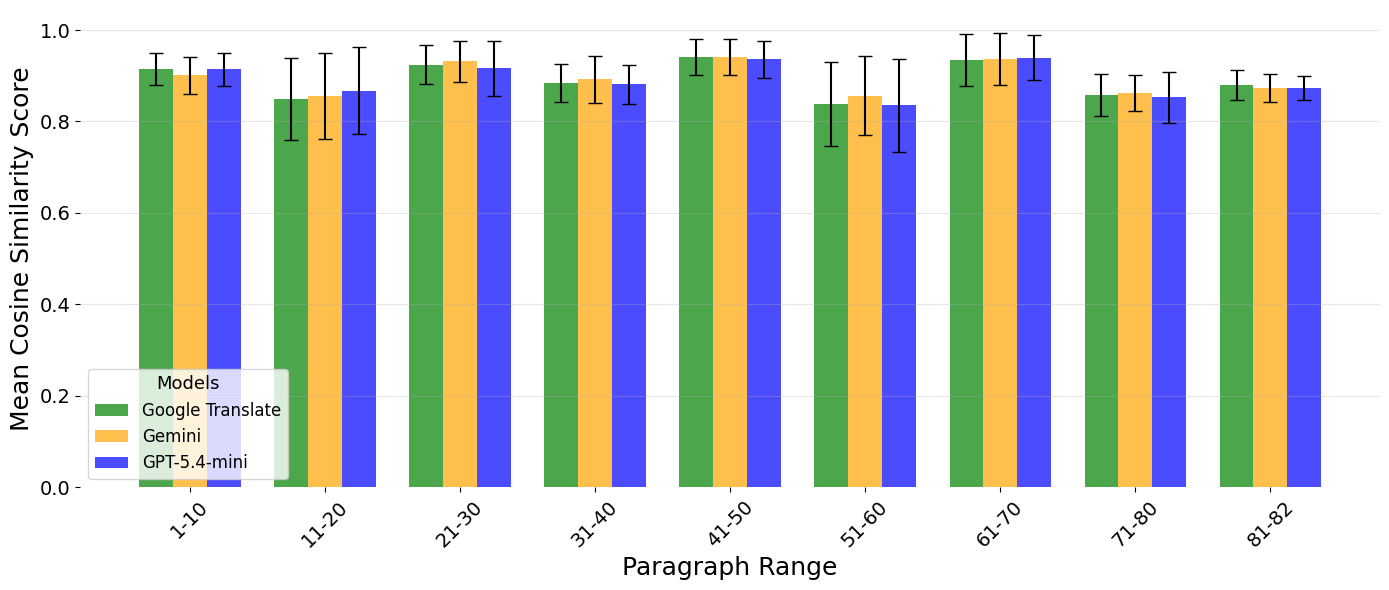

In [235]:
plot_error_bar_graph(
    file_path="results/bul_news/similarity/cosine_similarity.csv",
    output_path="results/bul_news/similarity/cosine_similarity_errorbars.png",
    bin_size=10
)

In [269]:
#Georgian Poems

texts_path = 'Data/Georgian/Vazha_ThreePoems/'
file_paths = ["orig/combined_vazha_poems_ge.csv", 
              "en/combined_vazha_poems_en.csv",
              "gem/combined_vazha_poems_gem.csv",
              "ggl/combined_vazha_poems_ggl.csv",
              "gpt/combined_vazha_poems_gpt.csv"]

article_names, df_orig, df_en, df_ggl, df_gem, df_gpt = text_name(texts_path, file_paths)

['01_aluda_ketelauri_ge.csv', '02_host_and_guest_ge.csv', '03_the_snake_eater_ge.csv']
3


In [270]:
df = paragraphs_func(article_names, df_orig, df_en, df_ggl, df_gem, df_gpt)
df.to_csv('results/all_ge_poems.csv', index = False)

In [271]:
df = cosine_sim('results/all_ge_poems.csv', model, 'results/ge_poems/similarity/cosine_similarity.csv')

In [272]:
cols_to_move = ['English - Google', 'English - Gemini', 'English - ChatGPT']
remaining_cols = [c for c in df.columns if c not in cols_to_move]
target_idx = remaining_cols.index('Paragraph') + 1

new_order = remaining_cols[:target_idx] + cols_to_move + remaining_cols[target_idx:]
df = df[new_order]

for article, group_df in df.groupby('Article ID'):
    group_df.to_csv(f'results/ge_poems/similarity/cosine_similarity_{article}.csv', index=False)

mean_std(df)

         Article Name  English - Google  English - Google  English - Gemini  \
1  Aluda Ketelauri Ge          0.696324          0.120564          0.800244   
2   Host And Guest Ge          0.735231          0.112632          0.790969   
3  The Snake Eater Ge          0.731585          0.139171          0.801443   

   English - Gemini  English - ChatGPT  English - ChatGPT  
1          0.104567           0.767214           0.112404  
2          0.108603           0.786643           0.107404  
3          0.118678           0.791924           0.111838  
Google 0.7210469 0.12412226
Gemini 0.79755163 0.110616006
ChatGPT 0.7819271 0.110548876


In [273]:
max_min_cos(df)

Google 0.94065416 0.2340934
Gemini 0.9528129 0.25059256
ChatGPT 0.94998527 0.25394583
     Article ID        Article Name  Paragraph  English - Google  \
222           3  The Snake Eater Ge         68          0.234093   
69            2   Host And Guest Ge          7          0.343027   
23            1  Aluda Ketelauri Ge         24          0.466132   

     English - Gemini  English - ChatGPT  \
222          0.250593           0.392058   
69           0.292288           0.470602   
23           0.495849           0.371039   

                                                                                                                                                                                                                                                      Original  \
222                                                                                                                                                                                           (მეორე ქალი) უმი

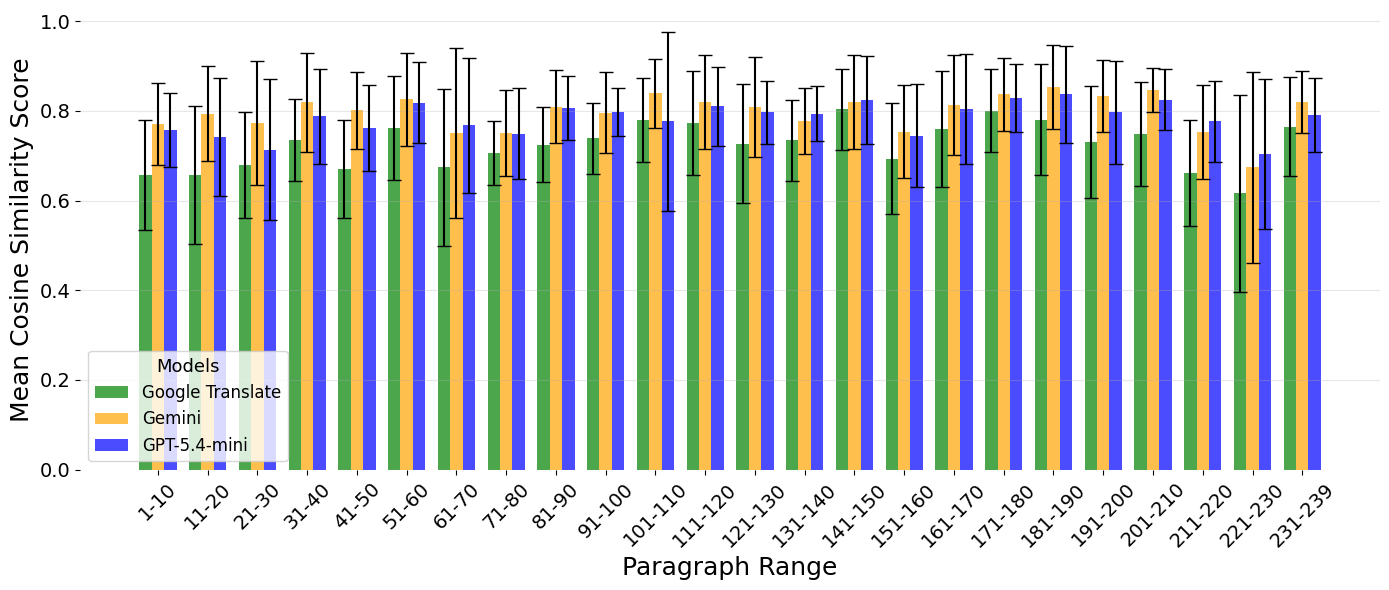

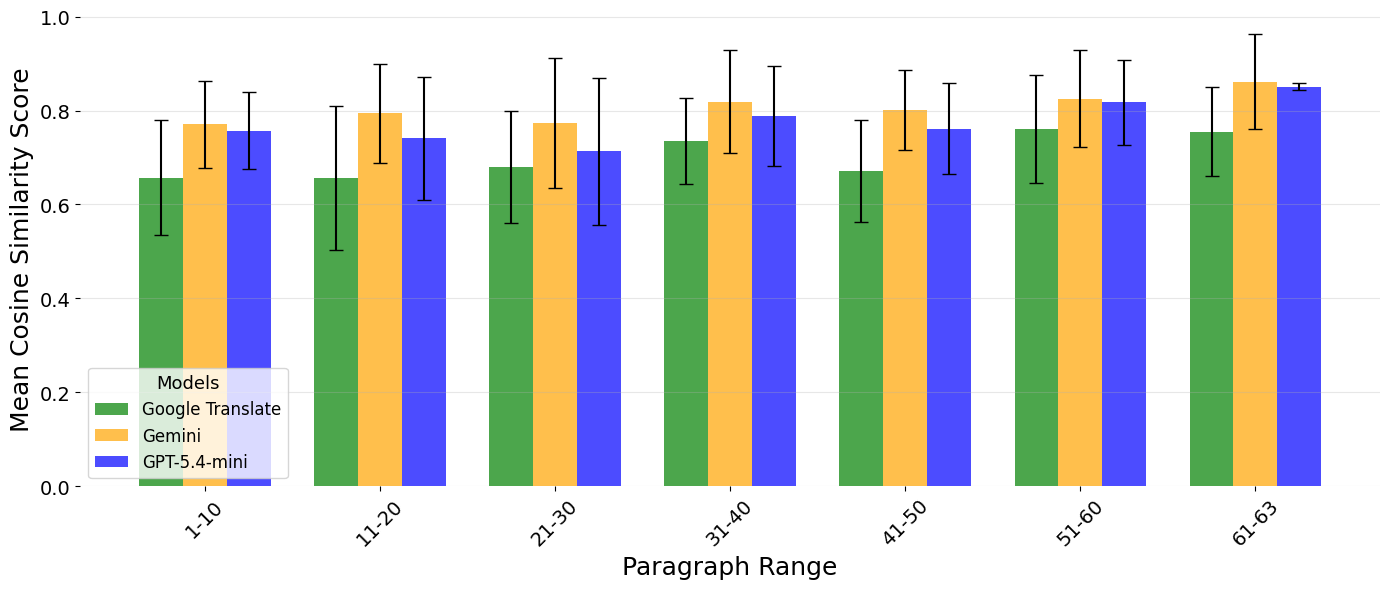

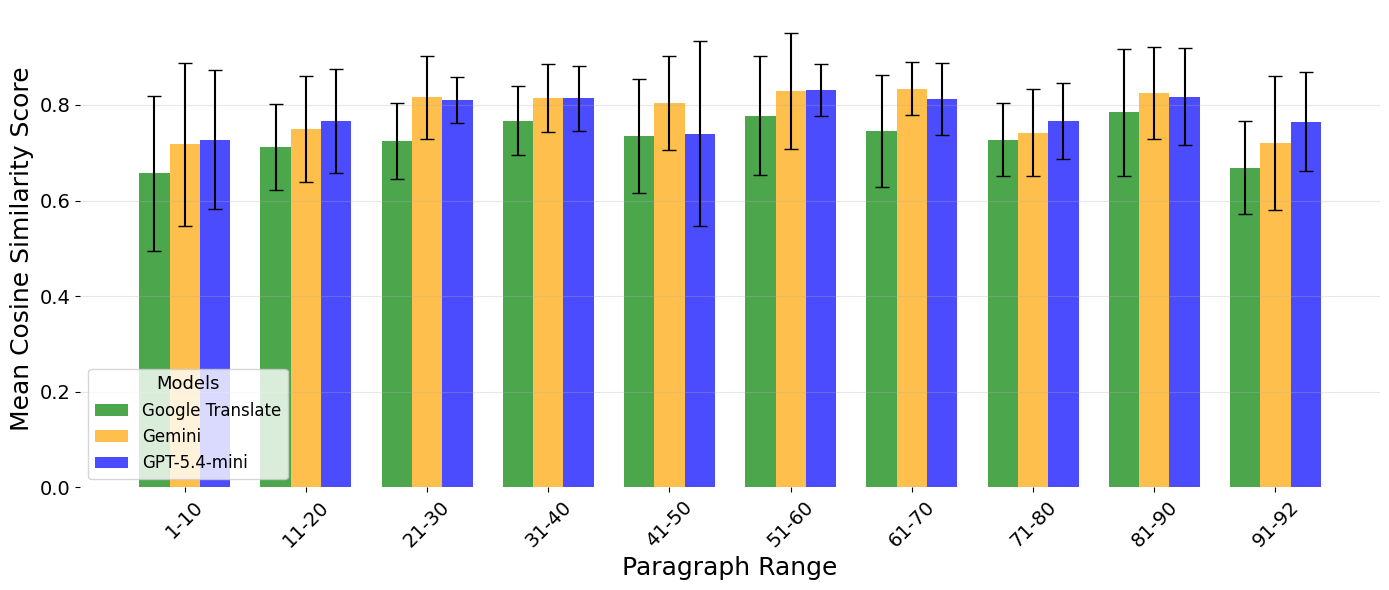

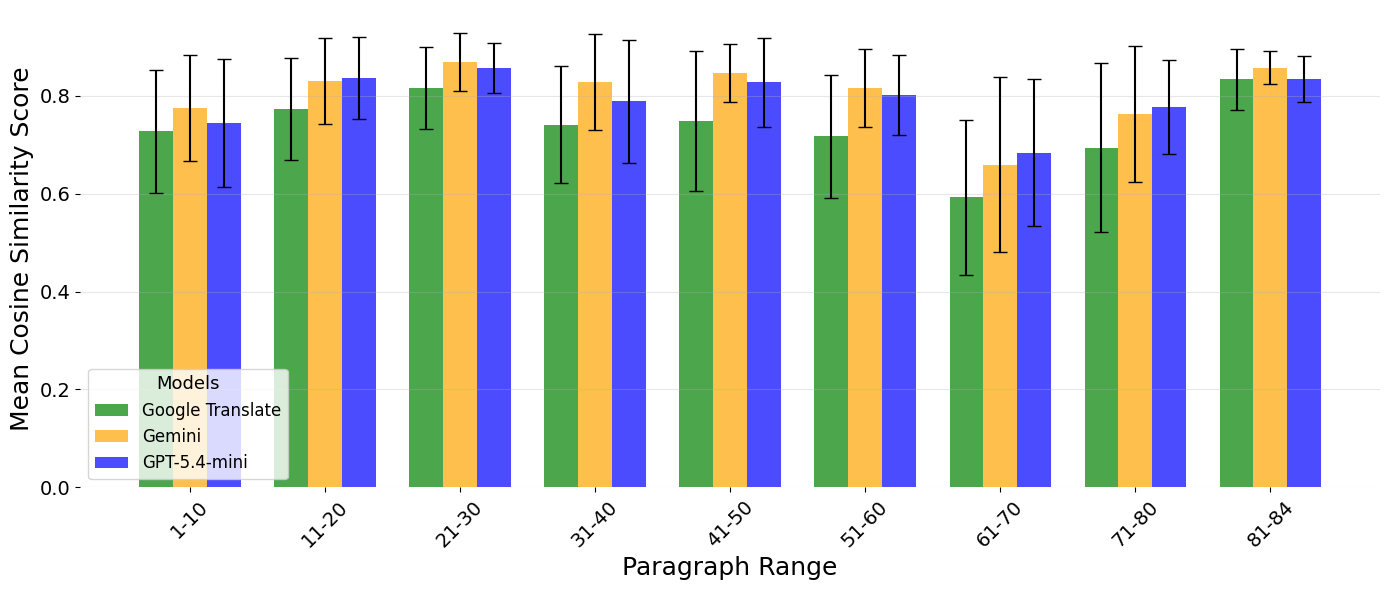

In [274]:
plot_error_bar_graph(
    file_path="results/ge_poems/similarity/cosine_similarity.csv",
    output_path="results/ge_poems/similarity/cosine_similarity_errorbars.png",
    bin_size=10
)

distinct_count = df['Article ID'].nunique()

for article in range(1, distinct_count + 1):
    plot_error_bar_graph(
    file_path=f"results/ge_poems/similarity/cosine_similarity_{article}.csv",
    output_path=f"results/ge_poems/similarity/cosine_similarity_errorbars_{article}.png",
    bin_size=10
)

In [256]:
#Bulgarian Prose

texts_path = 'Data/Bulgarian/BaiGanyo/'
file_paths = ["orig/baiganyo_combined_master_bul.csv", 
              "en/baiganyo_combined_master_en.csv",
              "gem/baiganyo_combined_master_gem.csv",
              "ggl/baiganyo_combined_master_ggl.csv",
              "gpt/baiganyo_combined_master_gpt.csv"]

article_names, df_orig, df_en, df_ggl, df_gem, df_gpt = text_name(texts_path, file_paths)


['00_bai_ganyo_starts_out_for_europe_bul.csv', '01_bai_ganyo_sets_off_bul.csv', '02_bai_ganyo_at_the_opera_bul.csv', '03_bai_ganyo_at_the_baths_bul.csv', '04_bai_ganyo_in_dresden_bul.csv', '05_bai_ganyo_at_the_prague_exhibition_bul.csv', '06_bai_ganyo_at_jirecheks_bul.csv', '07_bai_ganyo_goes_visiting_bul.csv', '08_bai_ganyo_in_switzerland_bul.csv', '09_bai_ganyo_in_russia_bul.csv', '10_bai_ganyo_returns_from_europe_bul.csv', '11_bai_ganyo_does_elections_bul.csv', '12_bai_ganyo_the_journalist_bul.csv', '13_bai_ganyo_at_the_palace_bul.csv', '14_bai_ganyo_in_the_delegation_bul.csv', '15_bai_ganyo_in_the_opposition_bul.csv', '16_the_temperance_society_bul.csv', '17_letter_from_bai_ganyo_to_konstantin_velichkov_bul.csv', '18_from_the_correspondence_of_bai_ganyo_balkanski_bul.csv']
19


In [257]:
df = paragraphs_func(article_names, df_orig, df_en, df_ggl, df_gem, df_gpt)
df.to_csv('results/all_bul_prose.csv', index=False)

In [258]:
df = cosine_sim('results/all_bul_prose.csv', model, 'results/bul_prose/similarity/cosine_similarity.csv')

In [259]:
cols_to_move = ['English - Google', 'English - Gemini', 'English - ChatGPT']
remaining_cols = [c for c in df.columns if c not in cols_to_move]
target_idx = remaining_cols.index('Paragraph') + 1

new_order = remaining_cols[:target_idx] + cols_to_move + remaining_cols[target_idx:]
df = df[new_order]

for article, group_df in df.groupby('Article ID'):
    group_df.to_csv(f'results/bul_prose/similarity/cosine_similarity_{article}.csv', index=False)

mean_std(df)

                                          Article Name  English - Google  \
1                           Bai Ganyo At Jirecheks Bul          0.802508   
2                           Bai Ganyo At The Baths Bul          0.744478   
3                           Bai Ganyo At The Opera Bul          0.706124   
4                          Bai Ganyo At The Palace Bul          0.787375   
5               Bai Ganyo At The Prague Exhibition Bul          0.847319   
6                         Bai Ganyo Does Elections Bul          0.812624   
7                          Bai Ganyo Goes Visiting Bul          0.826082   
8                             Bai Ganyo In Dresden Bul          0.844092   
9                              Bai Ganyo In Russia Bul          0.821027   
10                        Bai Ganyo In Switzerland Bul          0.788148   
11                     Bai Ganyo In The Delegation Bul          0.897024   
12                     Bai Ganyo In The Opposition Bul          0.804232   
13          

In [260]:
max_min_cos(df)

Google 1.0000002 0.16698636
Gemini 1.0000002 0.03934594
ChatGPT 1.0000002 0.10613443
     Article ID                                        Article Name  \
871          18  From The Correspondence Of Bai Ganyo Balkanski Bul   
879          18  From The Correspondence Of Bai Ganyo Balkanski Bul   
704          12                        Bai Ganyo The Journalist Bul   

     Paragraph  English - Google  English - Gemini  English - ChatGPT  \
871         16          0.231659          0.231659           0.281887   
879         24          0.228387          0.234751           0.284685   
704         46          0.595871          0.106134           0.106134   

                              Original                              English  \
871                              X. У.                            Anonymous   
879                     Поздравявам Ви                   With kind regards,   
704  — Ама отде-накъде да бъде попара?  “But where does he get gravy from?”   

                    

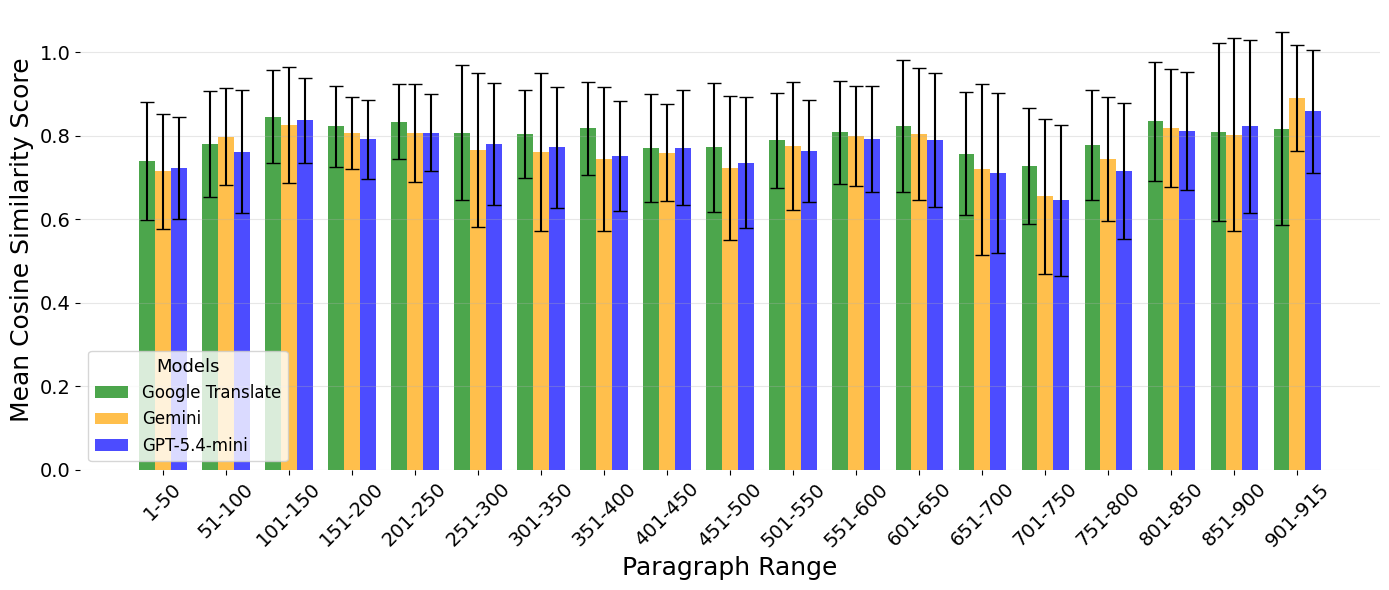

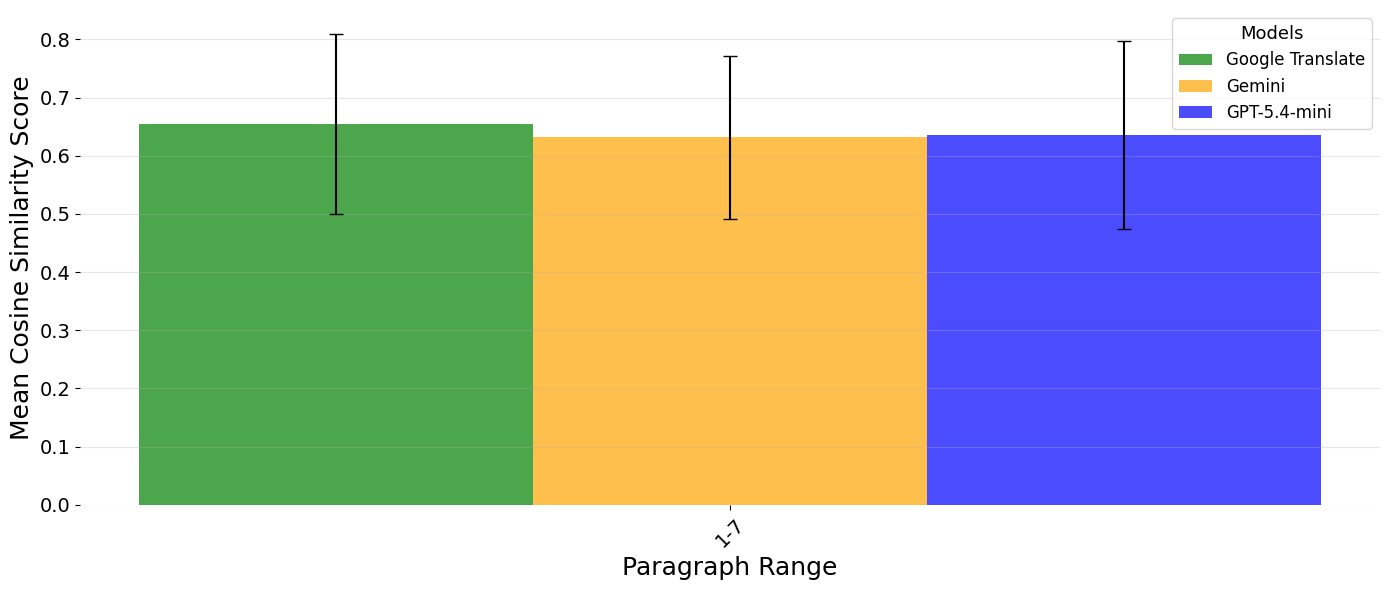

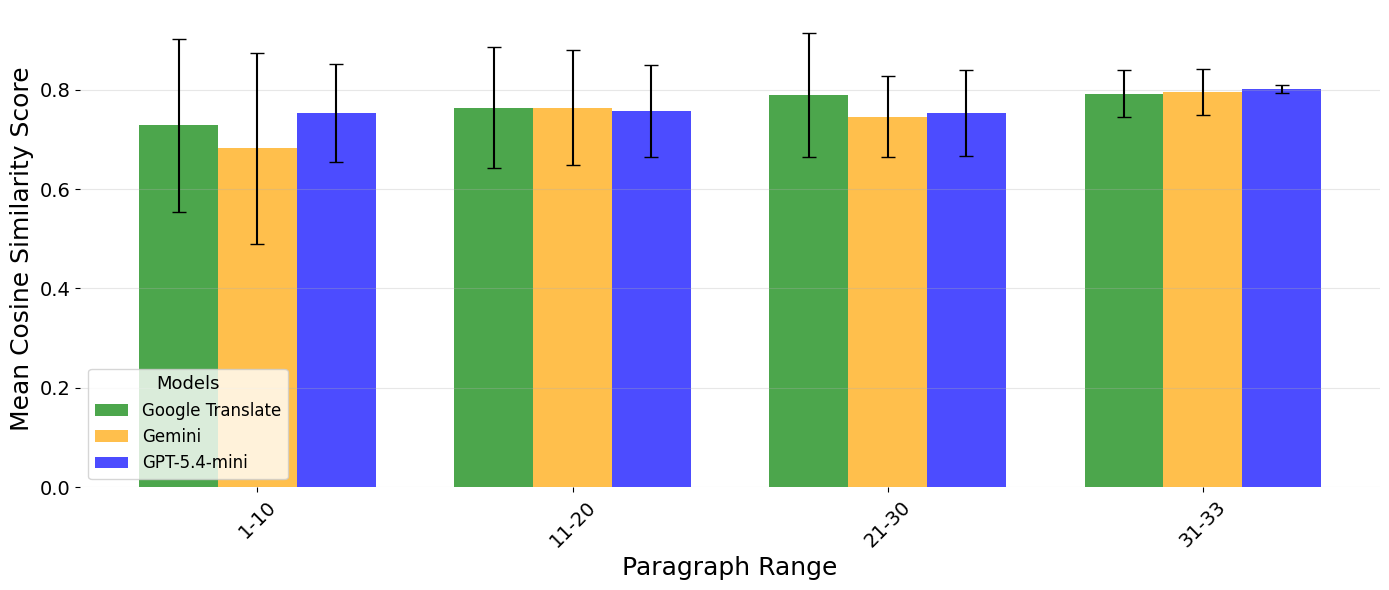

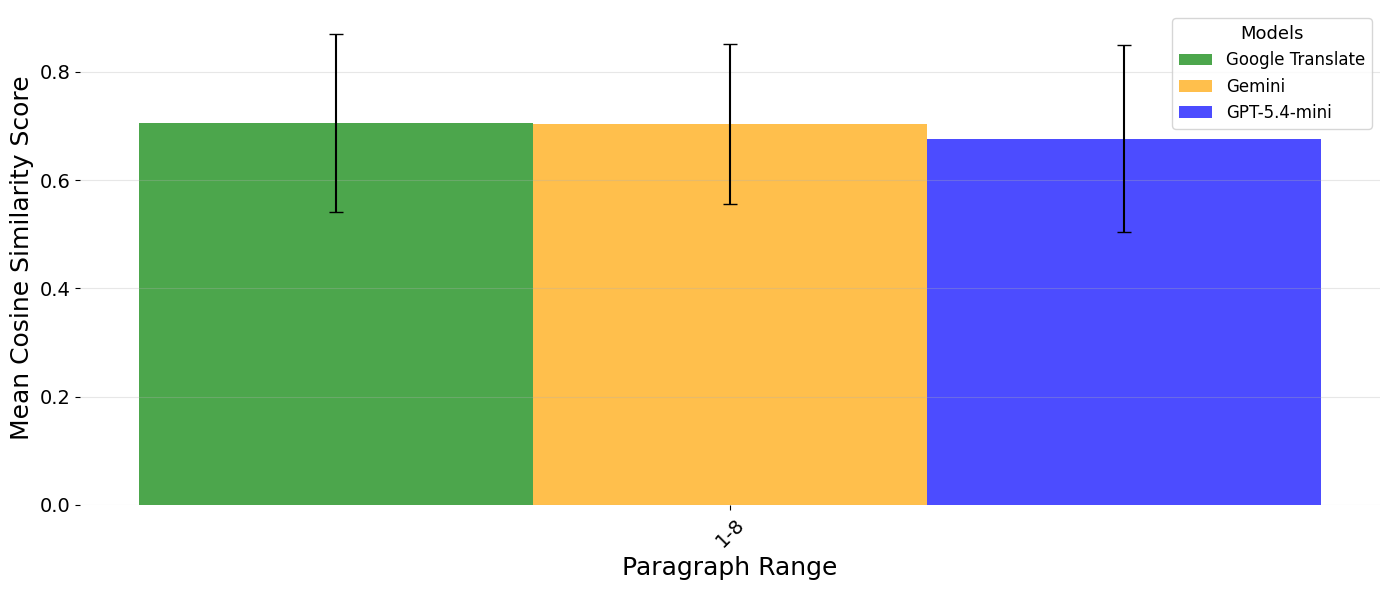

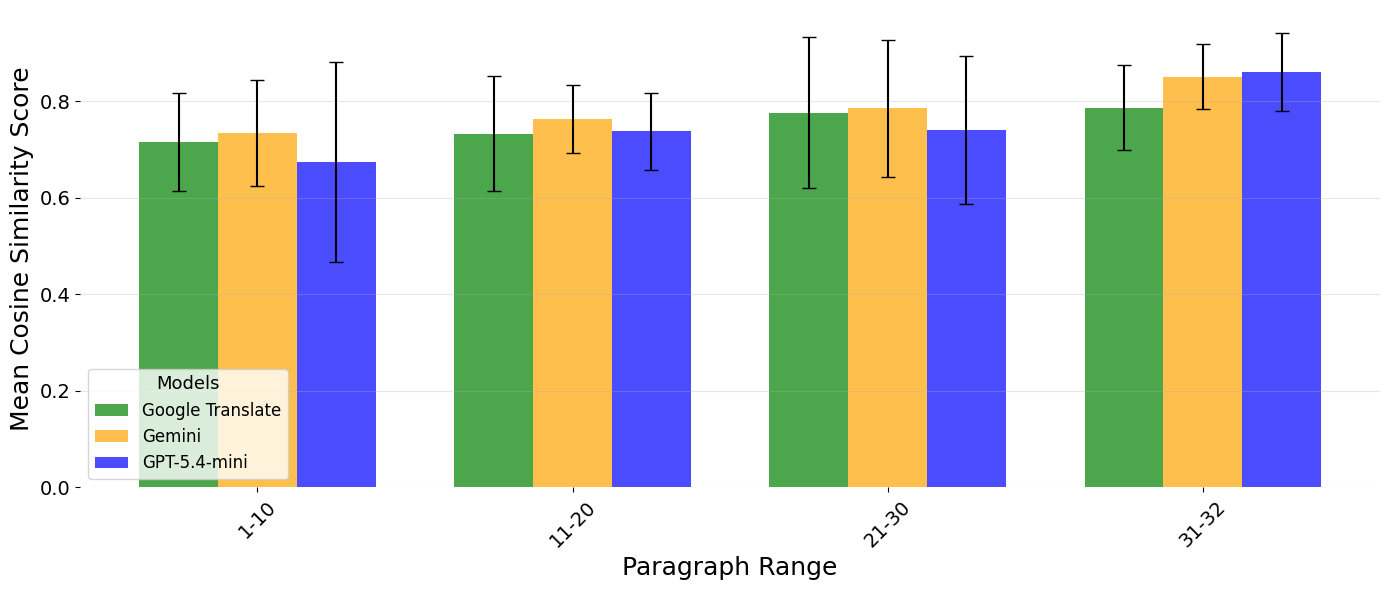

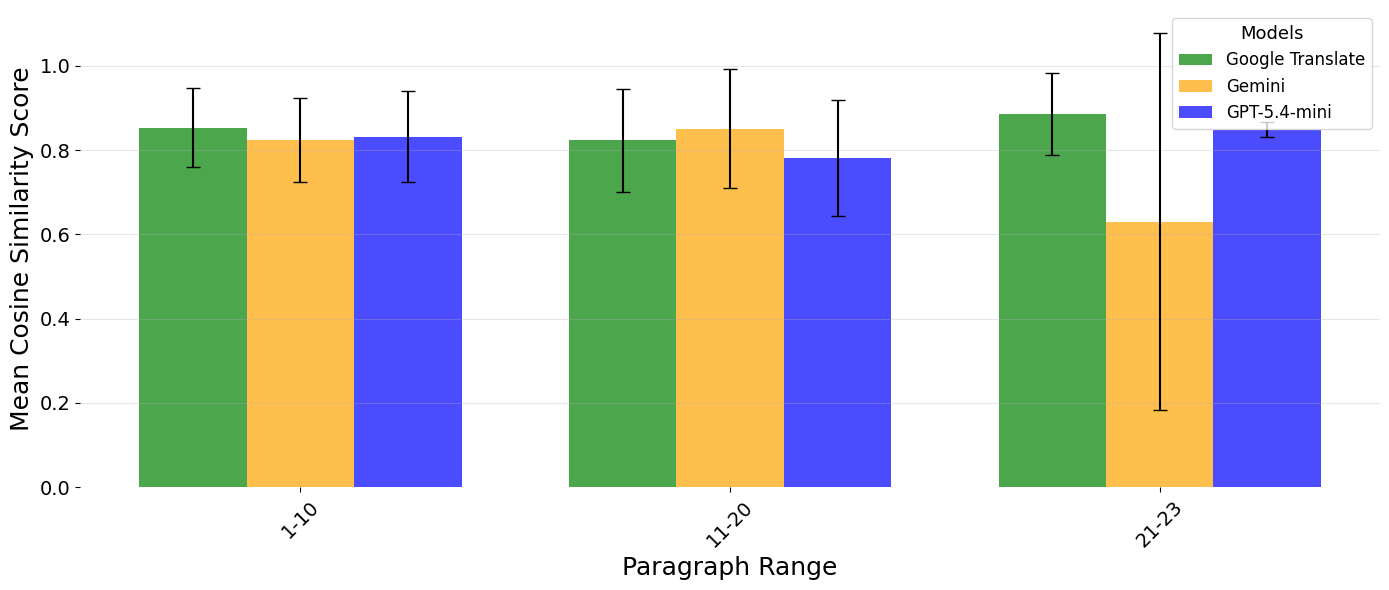

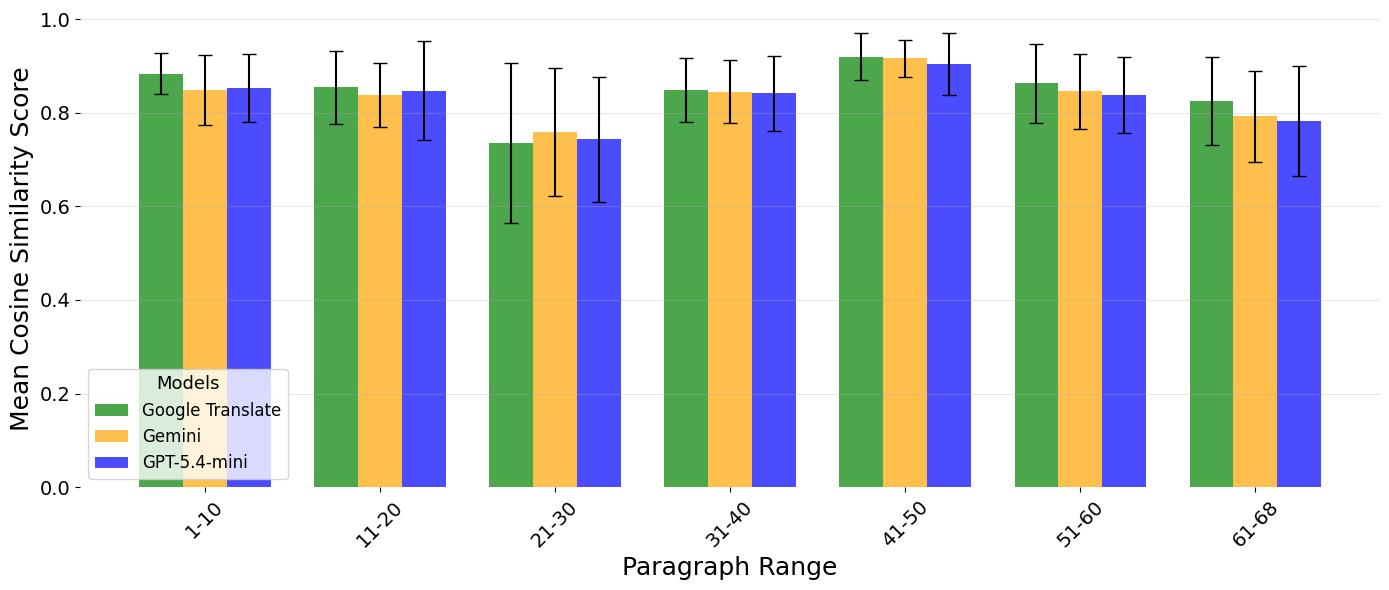

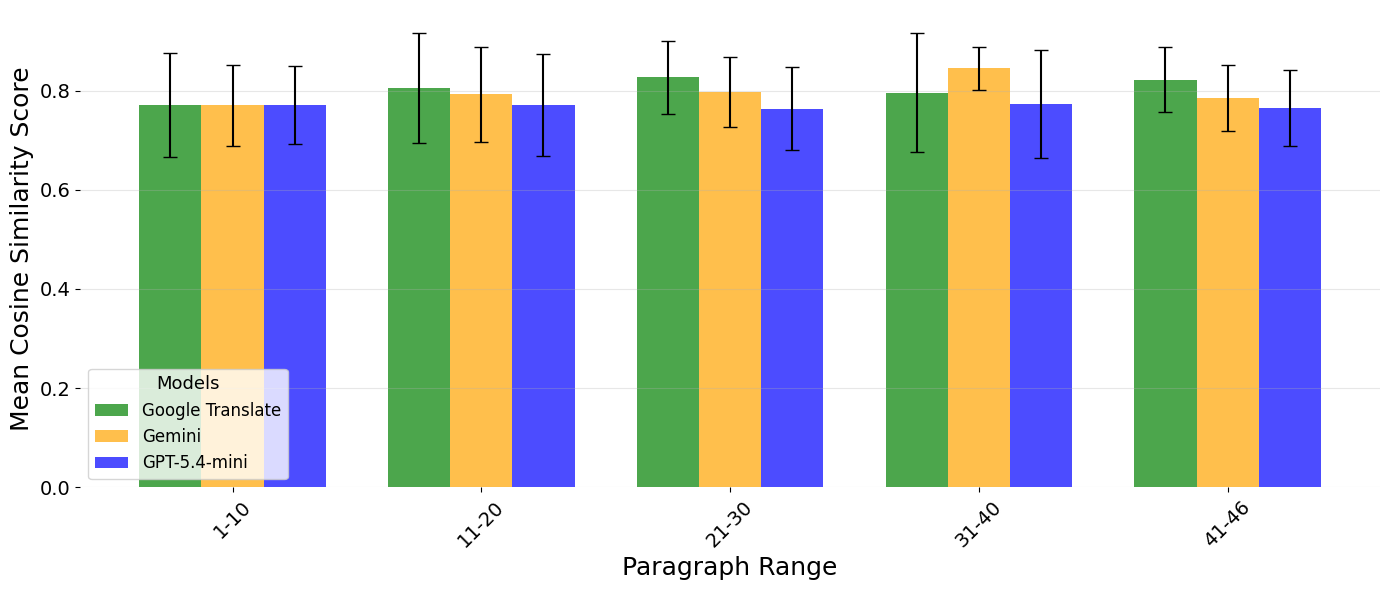

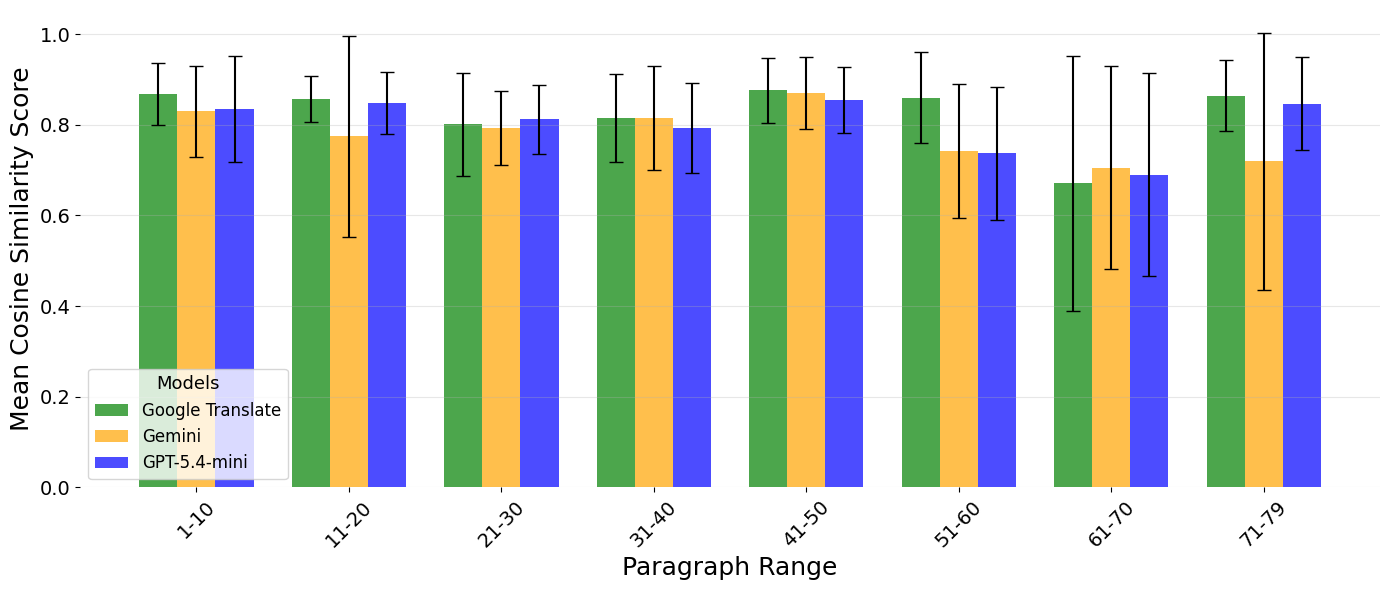

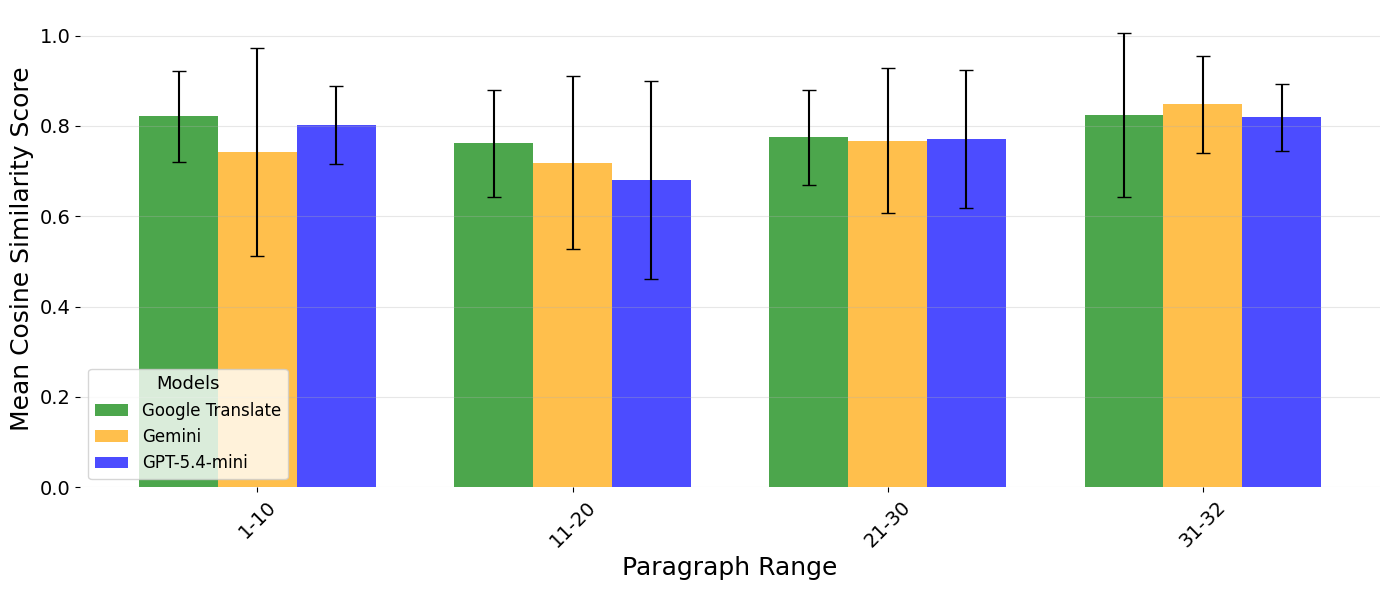

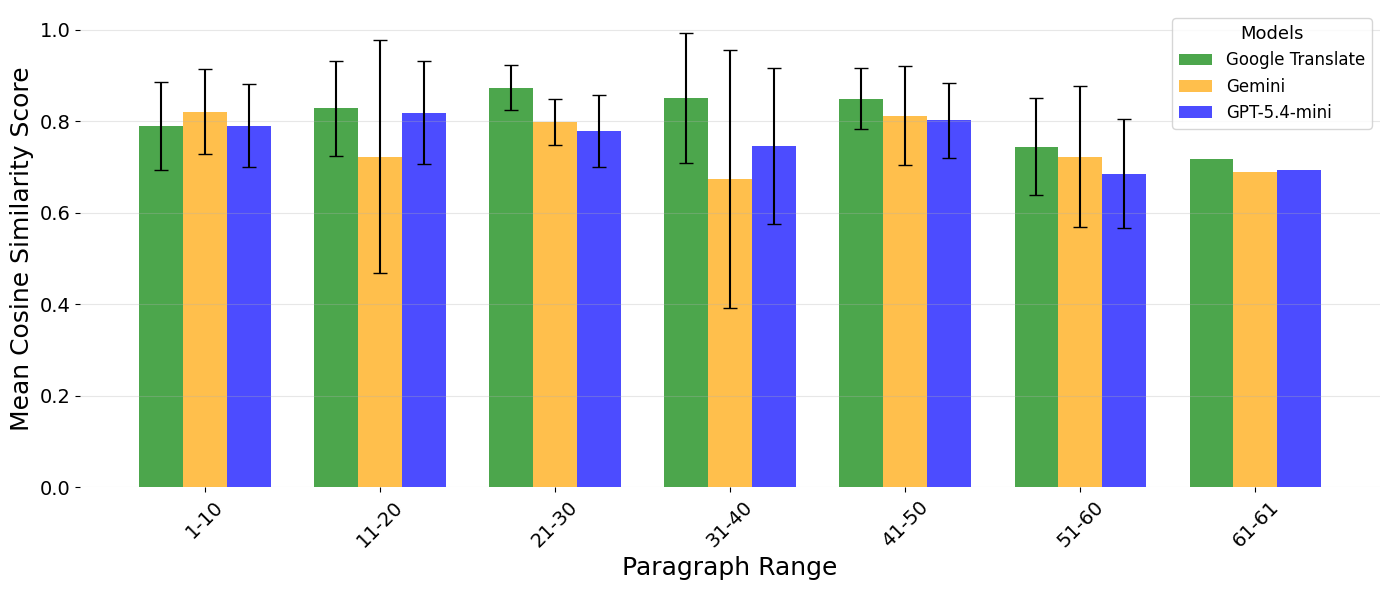

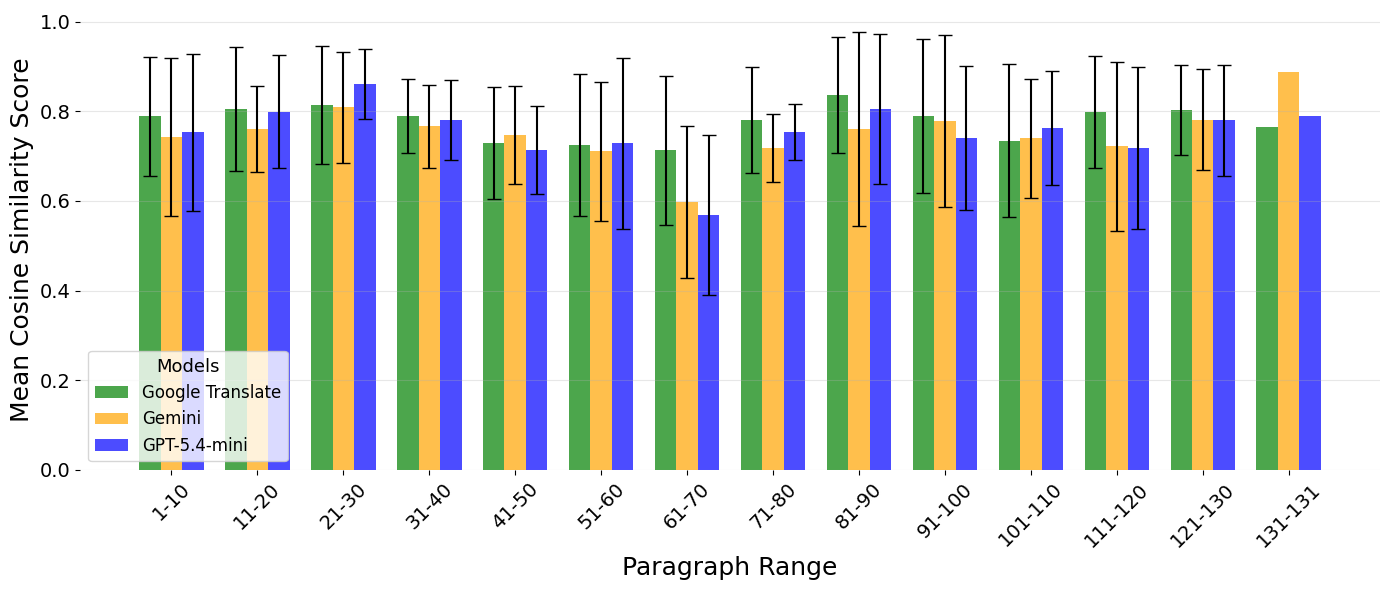

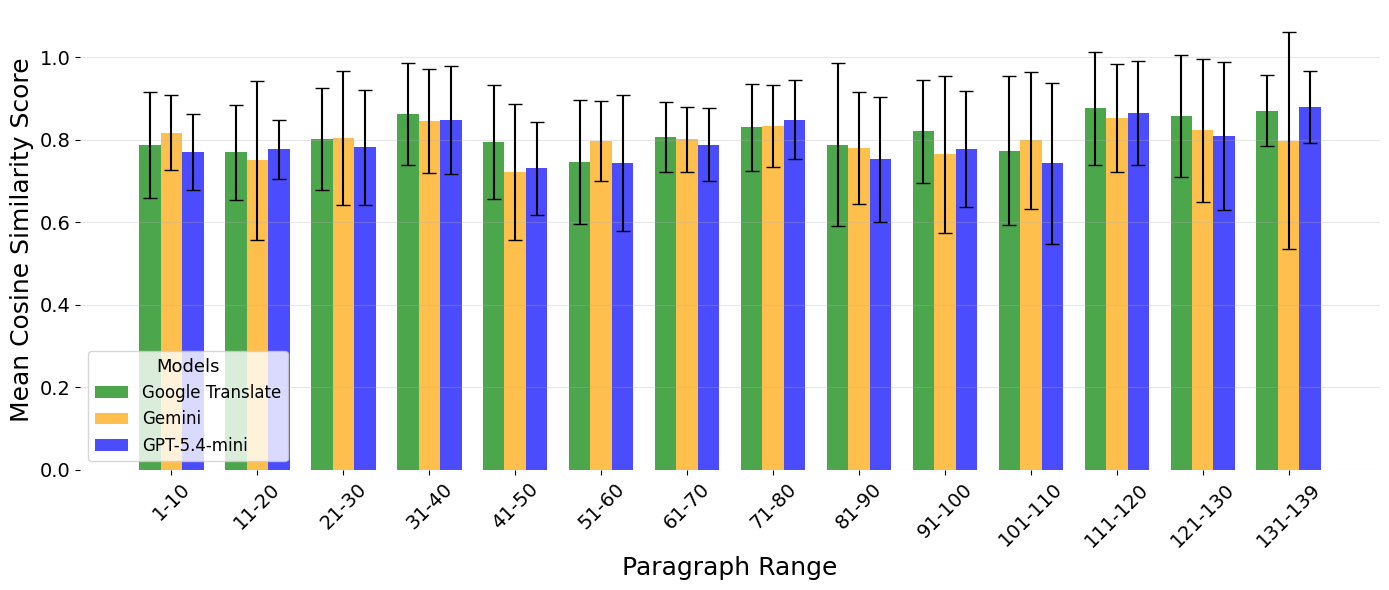

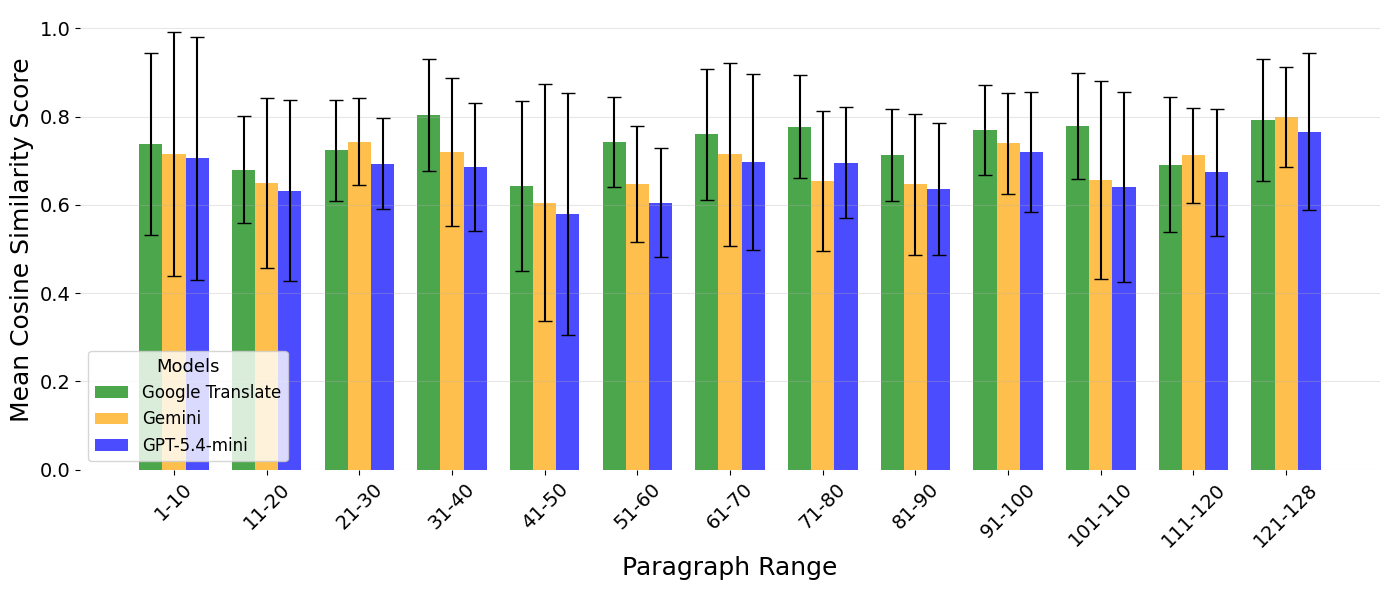

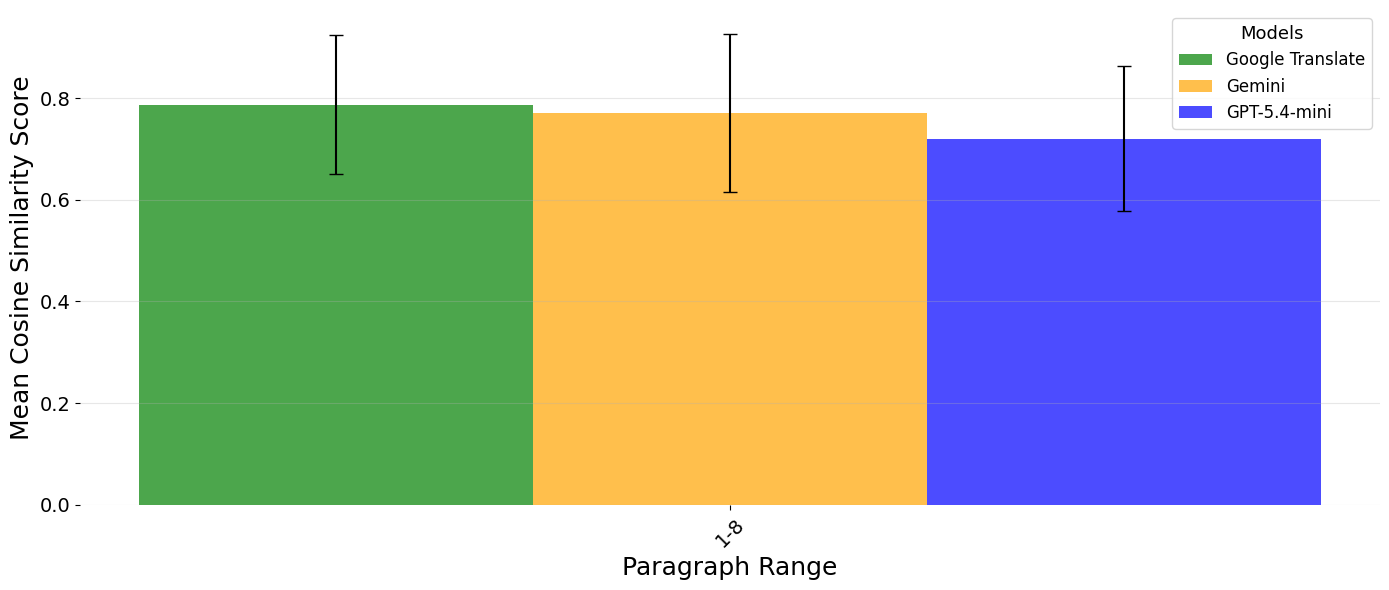

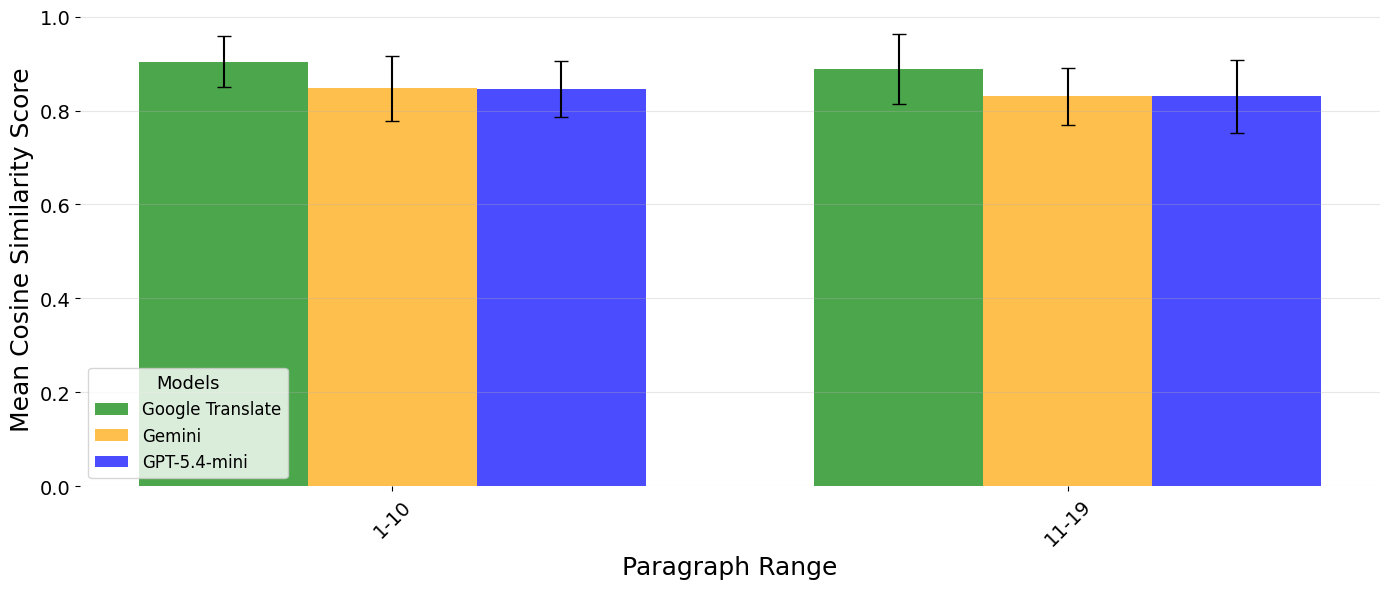

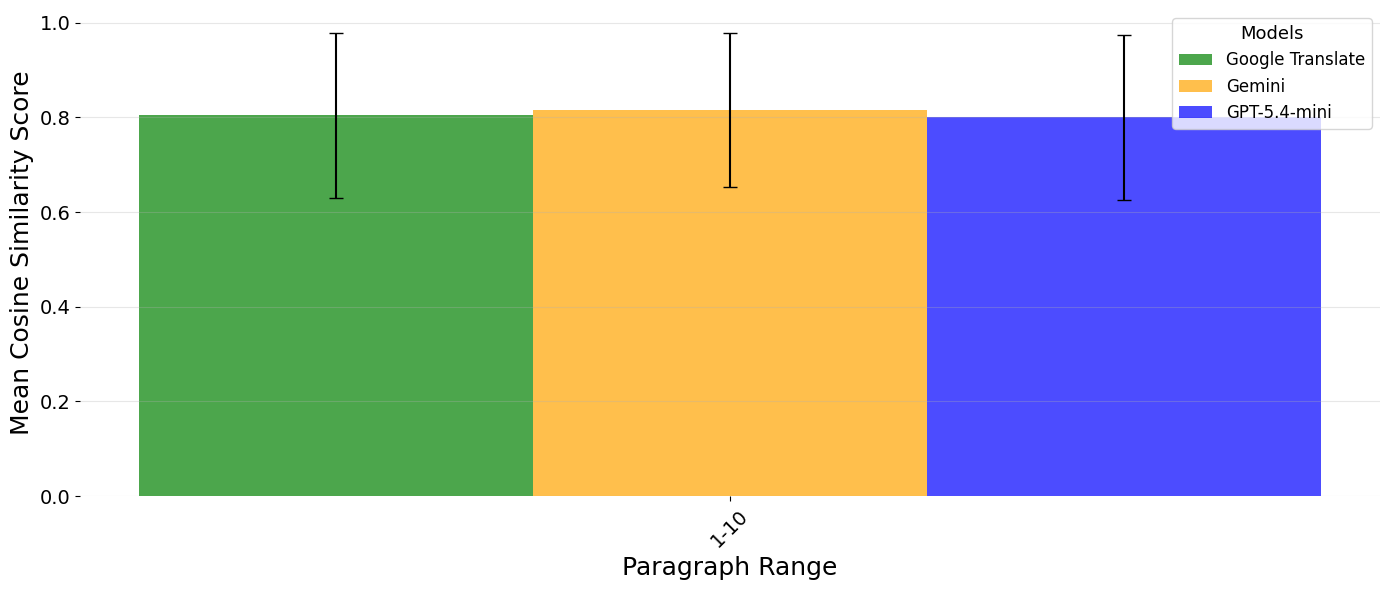

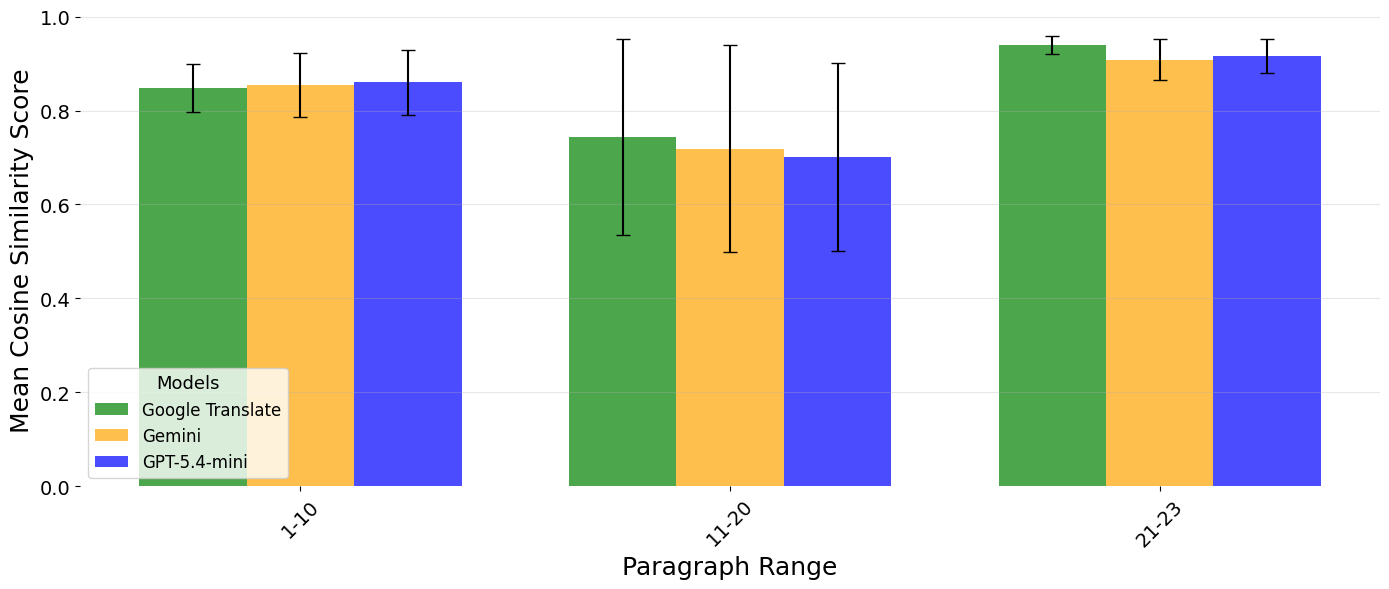

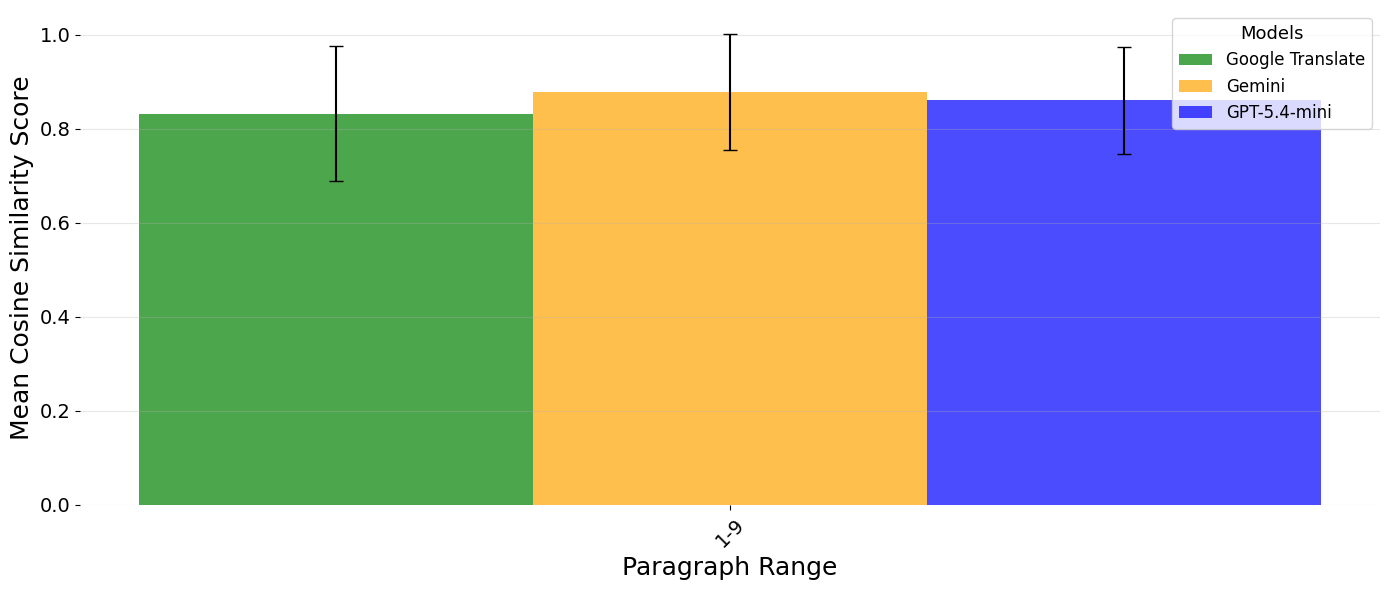

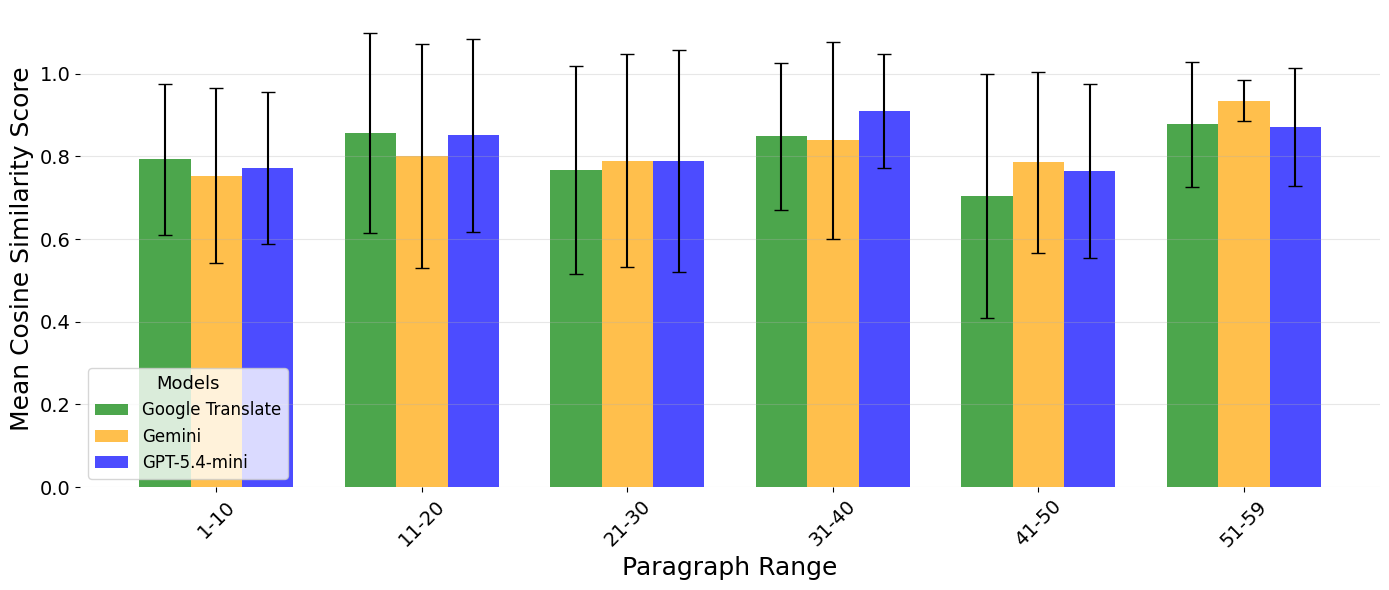

In [262]:
plot_error_bar_graph(
    file_path="results/bul_prose/similarity/cosine_similarity.csv",
    output_path="results/bul_prose/similarity/cosine_similarity_errorbars.png",
    bin_size=50
)

distinct_count = df['Article ID'].nunique()

for article in range(distinct_count):
    plot_error_bar_graph(
    file_path=f"results/bul_prose/similarity/cosine_similarity_{article}.csv",
    output_path=f"results/bul_prose/similarity/cosine_similarity_errorbars_{article}.png",
    bin_size=10
)